# FiftyOne Visual Debugging & TTA Dataset Inspection

**Goal**: Rapidly preview and validate FiftyOne multi-slice datasets, overlays, and diagnostic tags before launching the full evaluation suite.

## 1. Install & Load Dependencies

In [45]:
# Si falta alguna dependencia en el kernel, descomenta:
# %pip install -q fiftyone pillow pandas matplotlib

import os
import re
import sys
import importlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import fiftyone as fo
from fiftyone import ViewField as F
%matplotlib inline
%matplotlib notebook

# Añadir raíz del proyecto para imports locales
project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pose_uncertainty.evaluation.storage import load_deep_analysis
import src.pose_uncertainty.visualization.fiftyone_loader as fo_loader
fo_loader = importlib.reload(fo_loader)
_packet_to_samples = fo_loader._packet_to_samples
_CACHE_SUBDIR = fo_loader._CACHE_SUBDIR

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 10
print(f"Project root: {project_root}")
print("fiftyone_loader recargado")

Project root: C:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta
fiftyone_loader recargado


## 2. Configure Paths and Select Sample Packet

In [46]:
data_dir = project_root / "outputs" / "2026-02-11" / "12-40-42"
cache_dir = data_dir / _CACHE_SUBDIR
cache_dir.mkdir(parents=True, exist_ok=True)

pkl_files = sorted(data_dir.glob("*.pkl.gz"))
assert len(pkl_files) > 0, f"No hay .pkl.gz en {data_dir}"

# Elegimos automáticamente un paquete que genere varias slices
example_pkl = None
packet = None
for p in pkl_files:
    pkt = load_deep_analysis(str(p))
    tmp_samples = _packet_to_samples(pkt, cache_dir, fo)
    if len(tmp_samples) >= 3:
        example_pkl = p
        packet = pkt
        break

if example_pkl is None:
    example_pkl = pkl_files[0]
    packet = load_deep_analysis(str(example_pkl))

print("Paquete ejemplo:", example_pkl.name)
print("image_id:", packet.get("meta", {}).get("image_id"))
print("tta_data:", len(packet.get("tta_data", [])))

Paquete ejemplo: Edge_Cases_105912.pkl.gz
image_id: 105912
tta_data: 2


## 3. Automatically Discover FiftyOne Dataset Slices

In [47]:
samples = _packet_to_samples(packet, cache_dir, fo)
assert len(samples) > 0, "No se generaron samples"

image_paths = [Path(s.filepath) for s in samples]
for p in image_paths:
    assert p.exists(), f"No existe: {p}"

print(f"Slices generadas: {len(samples)}")
for s in samples:
    print(f"- {s['group'].name:20s} -> {Path(s.filepath).name}")

Slices generadas: 6
- original             -> Edge_Cases_105912_original.jpg
- mix_analysis         -> Edge_Cases_105912_mix_analysis.jpg
- tta_original_image   -> Edge_Cases_105912_tta_original_image.jpg
- tta_original_heatmaps -> Edge_Cases_105912_tta_original_heatmaps.jpg
- tta_flip_image       -> Edge_Cases_105912_tta_flip_image.jpg
- tta_flip_heatmaps    -> Edge_Cases_105912_tta_flip_heatmaps.jpg


## 4. Construct Debugging Dataset with Rich Metadata

In [48]:
dataset_name = "TFG_Debug_FiftyOne_Notebook"
if fo.dataset_exists(dataset_name):
    fo.delete_dataset(dataset_name)

dataset = fo.Dataset(dataset_name)
dataset.add_group_field("group", default="original")
dataset.add_samples(samples)

# metadatos de imagen en todas las slices del grupo
slice_names = sorted({s["group"].name for s in samples})
for s in dataset.select_group_slices(slice_names):
    p = Path(s.filepath)
    with Image.open(p) as im:
        w, h = im.size
        mode = im.mode
    s["width"] = int(w)
    s["height"] = int(h)
    s["channels"] = int(3 if mode in ("RGB", "P") else 1)
    s["file_size_bytes"] = int(p.stat().st_size)
    s["file_mtime"] = datetime.fromtimestamp(p.stat().st_mtime)
    s.save()

print(dataset)
print("Num groups:", len(dataset))
print("Num slices:", len(dataset.select_group_slices(slice_names)))

 100% |█████████████████████| 6/6 [565.0ms elapsed, 0s remaining, 10.6 samples/s]     
Name:        TFG_Debug_FiftyOne_Notebook
Media type:  group
Group slice: original
Num groups:  1
Persistent:  False
Tags:        []
Sample fields:
    id:                   fiftyone.core.fields.ObjectIdField
    filepath:             fiftyone.core.fields.StringField
    tags:                 fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.Metadata)
    created_at:           fiftyone.core.fields.DateTimeField
    last_modified_at:     fiftyone.core.fields.DateTimeField
    group:                fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.groups.Group)
    image_id:             fiftyone.core.fields.IntField
    sample_type:          fiftyone.core.fields.StringField
    oks_delta:            fiftyone.core.fields.FloatField
    nll:                  fiftyone.core.fields.FloatField
   

## 5. Add FiftyOne Fields (Tags, Split, Scale, Dimensions, Metrics)

In [49]:
slice_names = sorted({s["group"].name for s in samples})

def _slug_text(x: str) -> str:
    x = (x or "").strip().lower()
    x = re.sub(r"[^a-z0-9]+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x or "unknown"

sample_type_value = str(packet.get("meta", {}).get("sample_type", "unknown"))

updated = 0
prev_slice = dataset.group_slice
for active_slice in slice_names:
    dataset.group_slice = active_slice
    for s in dataset:
        slice_name = active_slice
        is_heatmap = ("heatmap" in slice_name) or (slice_name == "mix_analysis")

        sample_type = str(s["sample_type"]) if s.has_field("sample_type") else sample_type_value
        sample_type_slug = _slug_text(sample_type)
        s["sample_type"] = sample_type

        if s.has_field("tta_label") and s["tta_label"] is not None:
            tta_label = str(s["tta_label"])
            kind = "heatmaps" if "heatmaps" in slice_name else "image"
            slice_display_name = f"{tta_label} | {kind}"
            tta_slug = _slug_text(tta_label)
        elif s.has_field("tta_name") and s["tta_name"] is not None:
            tta_name = str(s["tta_name"])
            kind = "heatmaps" if "heatmaps" in slice_name else "image"
            slice_display_name = f"{tta_name} | {kind}"
            tta_slug = _slug_text(tta_name)
        else:
            slice_display_name = slice_name
            tta_slug = None

        s["slice_display_name"] = slice_display_name
        s["slice_type"] = "heatmap" if is_heatmap else "image"

        tags = set(s.tags or [])
        tags.update([
            "debug",
            "notebook",
            f"slice:{slice_name}",
            f"type:{sample_type_slug}",
            sample_type_slug,
        ])
        if tta_slug is not None:
            tags.update(["tta", f"tta:{tta_slug}"])

        s.tags = sorted(tags)
        s["split"] = "debug"
        s["source"] = "deep_profiling_packet"
        s["version"] = "v3_grouped_debug"
        s["compression"] = "jpeg"
        s["compression_quality"] = 95
        s["batch_name"] = data_dir.name
        s["status"] = "ok"
        s["is_heatmap_slice"] = bool(is_heatmap)
        s.save()
        updated += 1

dataset.group_slice = prev_slice

print(f"Campos + tags añadidos a todas las slices (actualizadas: {updated})")
print("Sample tags disponibles:", dataset.count_sample_tags())
print("Field schema:", sorted(dataset.get_field_schema().keys()))

Campos + tags añadidos a todas las slices (actualizadas: 6)
Sample tags disponibles: {'notebook': 1, 'slice:original': 1, 'type:edge_cases': 1, 'debug': 1, 'edge_cases': 1}
Field schema: ['batch_name', 'channels', 'compression', 'compression_quality', 'covariance_volume', 'created_at', 'entropy', 'file_mtime', 'file_size_bytes', 'filepath', 'gmm_ellipses', 'gmm_modes', 'ground_truth', 'group', 'height', 'id', 'image_id', 'is_heatmap_slice', 'last_modified_at', 'mc_samples', 'metadata', 'nll', 'oks_base', 'oks_delta', 'oks_ours', 'prediction_base', 'prediction_ours', 'sample_type', 'slice_display_name', 'slice_type', 'source', 'split', 'status', 'tags', 'tta_index', 'tta_label', 'tta_name', 'tta_params', 'uncertainty_ellipses', 'version', 'width']


In [50]:
# Tabla rápida para validar metadatos por slice
# (robusto a estados viejos de variables/view)
if "samples" in globals() and len(samples) > 0:
    slice_names_local = sorted({s["group"].name for s in samples})
else:
    slice_names_local = ["original"]

flat_view_local = dataset.select_group_slices(slice_names_local)

rows = []
for s in flat_view_local:
    rows.append({
        "slice": s["group"].name,
        "w": s["width"] if s.has_field("width") else None,
        "h": s["height"] if s.has_field("height") else None,
        "size_kb": round((s["file_size_bytes"] if s.has_field("file_size_bytes") else 0) / 1024, 1),
        "heatmap": s["is_heatmap_slice"] if s.has_field("is_heatmap_slice") else None,
    })

df_meta = pd.DataFrame(rows).sort_values(["slice"]).reset_index(drop=True)
df_meta

,slice,w,h,size_kb,heatmap
0,mix_analysis,1200,1500,109.5,True
1,original,500,375,84.8,False
2,tta_flip_heatmaps,1200,1500,110.7,True
3,tta_flip_image,500,375,82.4,False
4,tta_original_heatmaps,1200,1500,92.6,True
5,tta_original_image,500,375,84.8,False


## 6. Attach Diagnostic Pose Overlays

In [51]:
# Añadimos etiquetas demo solo cuando no existan, para validar render del panel lateral
# (robusto a estados viejos de variables/view)
if "samples" in globals() and len(samples) > 0:
    slice_names_local = sorted({s["group"].name for s in samples})
else:
    slice_names_local = ["original"]

flat_view_local = dataset.select_group_slices(slice_names_local)

def maybe_add_debug_labels(sample):
    if not sample.has_field("debug_class"):
        sample["debug_class"] = fo.Classification(label="ok", confidence=0.99)

    if not sample.has_field("debug_box"):
        sample["debug_box"] = fo.Detections(detections=[
            fo.Detection(label="roi", bounding_box=[0.1, 0.1, 0.8, 0.8], confidence=0.8)
        ])

    if not sample.has_field("debug_poly"):
        sample["debug_poly"] = fo.Polylines(polylines=[
            fo.Polyline(points=[[(0.1, 0.1), (0.9, 0.1), (0.9, 0.9), (0.1, 0.9)]], closed=True, filled=False, label="frame")
        ])

    if not sample.has_field("debug_kps"):
        sample["debug_kps"] = fo.Keypoints(keypoints=[
            fo.Keypoint(points=[(0.2, 0.2), (0.8, 0.2), (0.5, 0.8)], label="triad")
        ])

    sample.save()

for s in flat_view_local:
    maybe_add_debug_labels(s)

print("Anotaciones debug añadidas en todas las slices")

Anotaciones debug añadidas en todas las slices


## 7. Configure FiftyOne Filter Views and Sort Orders

In [52]:
slice_names = sorted({s["group"].name for s in samples})
flat_view = dataset.select_group_slices(slice_names)

view_all = flat_view.sort_by("file_size_bytes", reverse=True)
view_heatmaps = flat_view.match(F("is_heatmap_slice") == True).sort_by("file_size_bytes", reverse=True)
view_original = flat_view.match(F("group.name") == "original")

# Filtros por tipo usando sample tags (type:...)
view_wins = flat_view.match(F("tags").contains("type:wins"))
view_regressions = flat_view.match(F("tags").contains("type:regressions"))
view_high_uncertainty = flat_view.match(F("tags").contains("type:high_uncertainty"))
view_edge_cases = flat_view.match(F("tags").contains("type:edge_cases"))

print("group_count (len dataset):", len(dataset))
print("slice_count (len flat_view):", len(flat_view))
print("view_heatmaps:", len(view_heatmaps))
print("view_original:", len(view_original))
print("view_wins:", len(view_wins))
print("view_regressions:", len(view_regressions))
print("view_high_uncertainty:", len(view_high_uncertainty))
print("view_edge_cases:", len(view_edge_cases))

flat_view.select_fields([
    "group", "slice_display_name", "tta_name", "sample_type",
    "image_id", "width", "height", "file_size_bytes",
    "is_heatmap_slice", "split", "status", "tags"
]).head(8)

group_count (len dataset): 1
slice_count (len flat_view): 6
view_heatmaps: 3
view_original: 1
view_wins: 0
view_regressions: 0
view_high_uncertainty: 0
view_edge_cases: 6


[<SampleView: {
     'id': '698f5248ec2397327dadf0c1',
     'media_type': 'image',
     'filepath': 'C:\\Users\\Santiago estudio\\Desktop\\TFG_Informatica\\robust-pose-tta\\outputs\\2026-02-11\\12-40-42\\fiftyone_cache\\Edge_Cases_105912_original.jpg',
     'tags': [
         'debug',
         'edge_cases',
         'notebook',
         'slice:original',
         'type:edge_cases',
     ],
     'metadata': None,
     'created_at': datetime.datetime(2026, 2, 13, 16, 33, 12, 897000),
     'last_modified_at': datetime.datetime(2026, 2, 13, 16, 33, 14, 494000),
     'group': <Group: {'id': '698f5247ec2397327dadf033', 'name': 'original'}>,
     'image_id': 105912,
     'sample_type': 'Edge_Cases',
     'tta_name': None,
     'width': 500,
     'height': 375,
     'file_size_bytes': 86816,
     'slice_display_name': 'original',
     'split': 'debug',
     'status': 'ok',
     'is_heatmap_slice': False,
 }>,
 <SampleView: {
     'id': '698f5249ec2397327dadf0c2',
     'media_type': 'image',
  

## 8. Local Matplotlib Preview of FiftyOne Visualizations

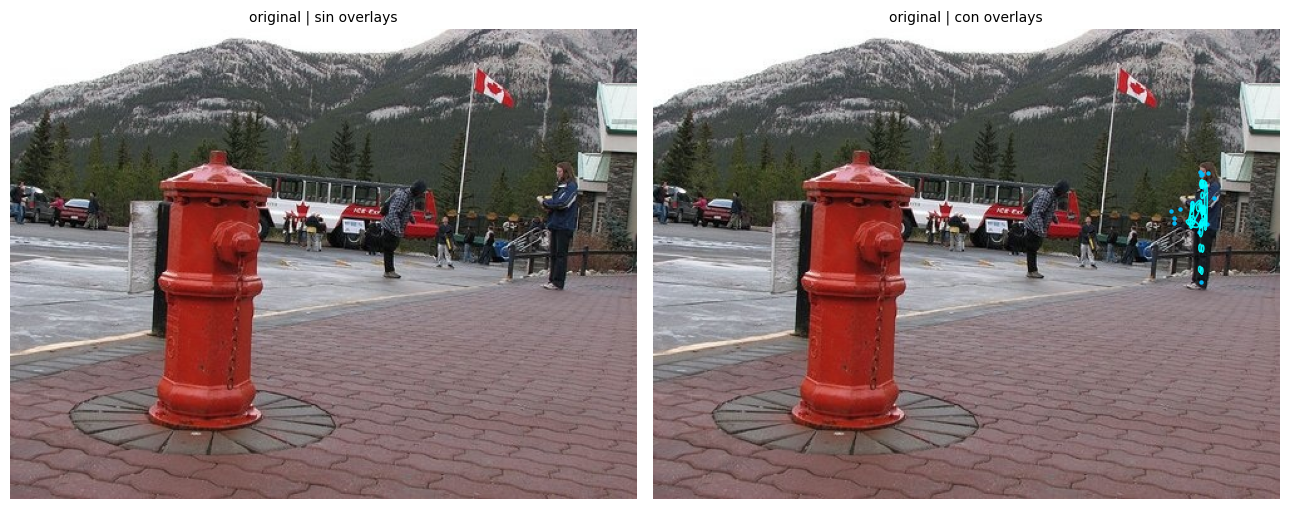

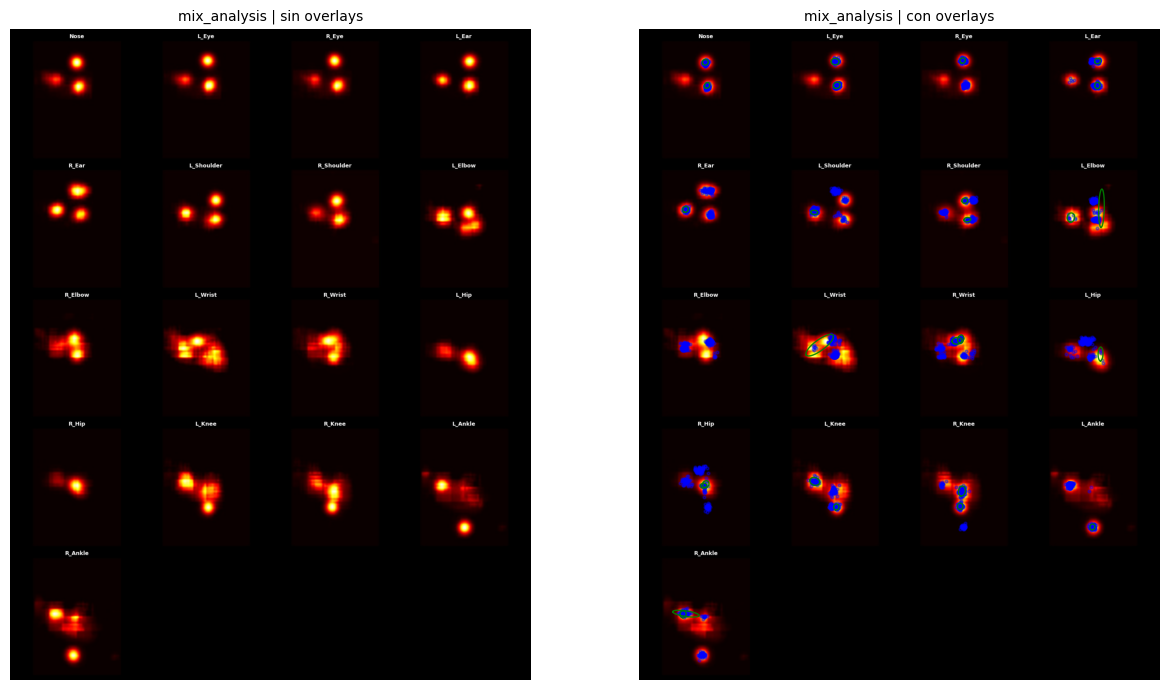

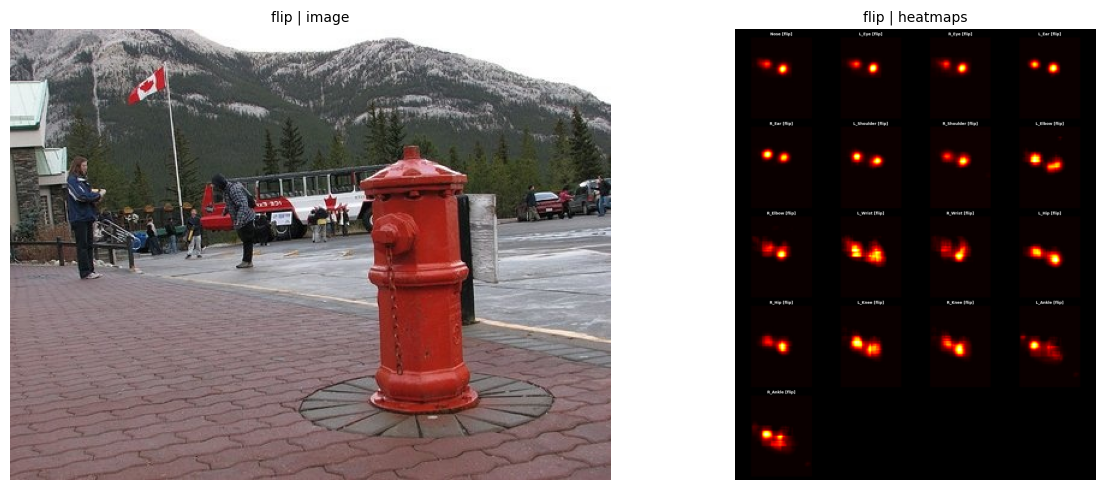

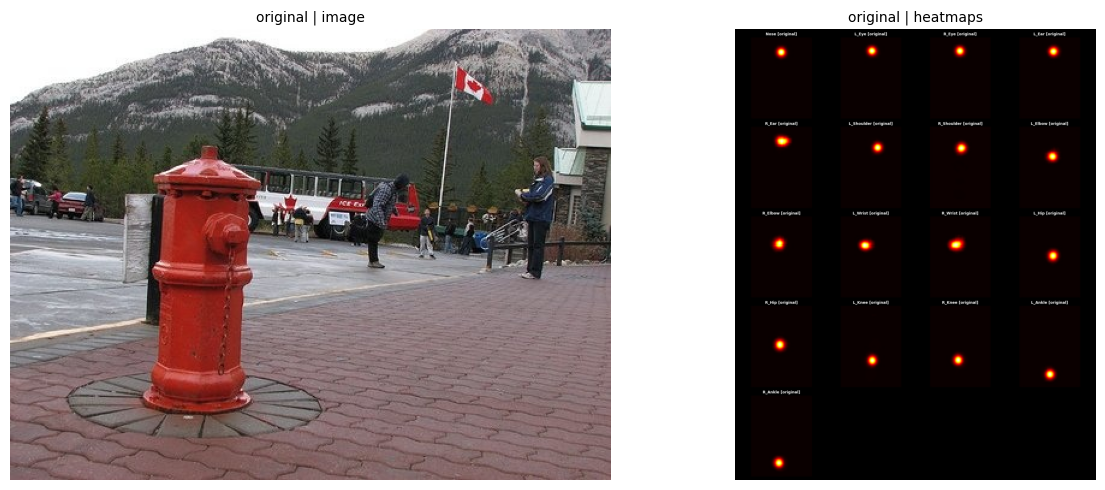

,bloque,slice,overlays_aplicados,shape
0,mix_analysis,mix_analysis,"mc_samples, gmm_ellipses",1200x1500
1,original,original,"prediction_ours, uncertainty_ellipses",500x375
2,tta_pair,flip | heatmaps,,1200x1500
3,tta_pair,flip | image,,500x375
4,tta_pair,original | heatmaps,,1200x1500
5,tta_pair,original | image,,500x375


In [53]:
# Vista detallada por separado (dentro del notebook)
# 1) Imagen original: overlays configurables
# 2) Heatmap promedio: overlays configurables
# 3) TTA: imagen y heatmap lado a lado por cada TTA

# ----------------------------
# Configuración de overlays
# ----------------------------
# ORIGINAL
ORIG_SHOW_GT = False
ORIG_SHOW_PRED_BASE = False
ORIG_SHOW_PRED_OURS = True
ORIG_SHOW_UNCERTAINTY = True

# HEATMAP PROMEDIO (mix_analysis)
MIX_SHOW_MC_SAMPLES = True
MIX_SHOW_GMM_ELLIPSES = True

# DEBUG EXTRA
SHOW_DEBUG_LABELS = False

# Garantizar vista válida aunque haya cambios de estado
if "samples" in globals() and len(samples) > 0:
    slice_names_local = sorted({s["group"].name for s in samples})
else:
    slice_names_local = sorted(dataset.distinct("group.name"))

flat_view_local = dataset.select_group_slices(slice_names_local)
samples_by_slice = {s["group"].name: s for s in flat_view_local}


def _draw_keypoint_like(ax, obj, w, h, color="lime", size=18, alpha=0.9):
    if obj is None:
        return

    # fo.Keypoint -> obj.points
    if hasattr(obj, "points") and obj.points is not None:
        pts = obj.points
        xs = [float(p[0]) * w for p in pts]
        ys = [float(p[1]) * h for p in pts]
        ax.scatter(xs, ys, c=color, s=size, alpha=alpha)

    # fo.Keypoints -> obj.keypoints
    if hasattr(obj, "keypoints") and obj.keypoints is not None:
        for kp in obj.keypoints:
            if kp is None or not hasattr(kp, "points") or kp.points is None:
                continue
            xs = [float(p[0]) * w for p in kp.points]
            ys = [float(p[1]) * h for p in kp.points]
            ax.scatter(xs, ys, c=color, s=size, alpha=alpha)


def _draw_polylines(ax, obj, w, h, color="cyan", lw=1.2, alpha=0.9):
    if obj is None or not hasattr(obj, "polylines") or obj.polylines is None:
        return

    for poly in obj.polylines:
        if poly is None or not hasattr(poly, "points") or poly.points is None:
            continue
        for contour in poly.points:
            if contour is None or len(contour) == 0:
                continue
            xs = [float(p[0]) * w for p in contour]
            ys = [float(p[1]) * h for p in contour]
            ax.plot(xs, ys, color=color, linewidth=lw, alpha=alpha)


def _draw_detections(ax, obj, w, h, color="yellow", lw=1.5, alpha=0.9):
    if obj is None or not hasattr(obj, "detections") or obj.detections is None:
        return

    for det in obj.detections:
        if det is None or not hasattr(det, "bounding_box") or det.bounding_box is None:
            continue
        x, y, bw, bh = det.bounding_box
        x *= w
        y *= h
        bw *= w
        bh *= h
        rect = plt.Rectangle((x, y), bw, bh, fill=False, edgecolor=color, linewidth=lw, alpha=alpha)
        ax.add_patch(rect)


def _apply_debug_overlays(ax, sample, w, h, present):
    if not SHOW_DEBUG_LABELS:
        return
    if sample.has_field("debug_kps") and sample["debug_kps"] is not None:
        _draw_keypoint_like(ax, sample["debug_kps"], w, h, color="magenta", size=5)
        present.append("debug_kps")
    if sample.has_field("debug_poly") and sample["debug_poly"] is not None:
        _draw_polylines(ax, sample["debug_poly"], w, h, color="white", lw=1.0)
        present.append("debug_poly")
    if sample.has_field("debug_box") and sample["debug_box"] is not None:
        _draw_detections(ax, sample["debug_box"], w, h, color="yellow", lw=1.3)
        present.append("debug_box")


preview_rows = []

# ==========================================================
# 1) Imagen original (sin/con overlays)
# ==========================================================
orig = samples_by_slice.get("original")
if orig is not None:
    img = np.array(Image.open(orig.filepath).convert("RGB"))
    h, w = img.shape[:2]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax0, ax1 = axes

    ax0.imshow(img)
    ax0.set_title("original | sin overlays")
    ax0.axis("off")

    ax1.imshow(img)
    ax1.set_title("original | con overlays")
    ax1.axis("off")

    present = []
    if ORIG_SHOW_GT and orig.has_field("ground_truth") and orig["ground_truth"] is not None:
        _draw_keypoint_like(ax1, orig["ground_truth"], w, h, color="lime", size=5)
        present.append("ground_truth")

    if ORIG_SHOW_PRED_BASE and orig.has_field("prediction_base") and orig["prediction_base"] is not None:
        _draw_keypoint_like(ax1, orig["prediction_base"], w, h, color="red", size=5)
        present.append("prediction_base")

    if ORIG_SHOW_PRED_OURS and orig.has_field("prediction_ours") and orig["prediction_ours"] is not None:
        _draw_keypoint_like(ax1, orig["prediction_ours"], w, h, color="deepskyblue", size=5)
        present.append("prediction_ours")

    if ORIG_SHOW_UNCERTAINTY and orig.has_field("uncertainty_ellipses") and orig["uncertainty_ellipses"] is not None:
        _draw_polylines(ax1, orig["uncertainty_ellipses"], w, h, color="cyan", lw=1.2)
        present.append("uncertainty_ellipses")

    _apply_debug_overlays(ax1, orig, w, h, present)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    preview_rows.append({
        "bloque": "original",
        "slice": "original",
        "overlays_aplicados": ", ".join(present),
        "shape": f"{w}x{h}",
    })

# ==========================================================
# 2) Heatmap promedio mix_analysis (sin/con overlays)
# ==========================================================
mix = samples_by_slice.get("mix_analysis")
if mix is not None:
    img = np.array(Image.open(mix.filepath).convert("RGB"))
    h, w = img.shape[:2]

    fig, axes = plt.subplots(1, 2, figsize=(13, 7))
    ax0, ax1 = axes

    ax0.imshow(img)
    ax0.set_title("mix_analysis | sin overlays")
    ax0.axis("off")

    ax1.imshow(img)
    ax1.set_title("mix_analysis | con overlays")
    ax1.axis("off")

    present = []
    if MIX_SHOW_MC_SAMPLES and mix.has_field("mc_samples") and mix["mc_samples"] is not None:
        _draw_keypoint_like(ax1, mix["mc_samples"], w, h, color="blue", size=4, alpha=0.35)
        present.append("mc_samples")

    if MIX_SHOW_GMM_ELLIPSES and mix.has_field("gmm_ellipses") and mix["gmm_ellipses"] is not None:
        _draw_polylines(ax1, mix["gmm_ellipses"], w, h, color="green", lw=1.0)
        present.append("gmm_ellipses")

    _apply_debug_overlays(ax1, mix, w, h, present)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    preview_rows.append({
        "bloque": "mix_analysis",
        "slice": "mix_analysis",
        "overlays_aplicados": ", ".join(present),
        "shape": f"{w}x{h}",
    })

# ==========================================================
# 3) Imágenes TTA y heatmaps al lado
# ==========================================================
tta_image_slices = sorted([k for k in samples_by_slice if k.startswith("tta_") and k.endswith("_image")])

for img_slice in tta_image_slices:
    hm_slice = img_slice.replace("_image", "_heatmaps")

    s_img = samples_by_slice.get(img_slice)
    s_hm = samples_by_slice.get(hm_slice)

    if s_img is None and s_hm is None:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax0, ax1 = axes

    if s_img is not None:
        arr = np.array(Image.open(s_img.filepath).convert("RGB"))
        title_img = s_img["slice_display_name"] if s_img.has_field("slice_display_name") else img_slice
        ax0.imshow(arr)
        ax0.set_title(title_img)
        ax0.axis("off")
        h0, w0 = arr.shape[:2]
        preview_rows.append({
            "bloque": "tta_pair",
            "slice": title_img,
            "overlays_aplicados": "",
            "shape": f"{w0}x{h0}",
        })
    else:
        ax0.text(0.5, 0.5, "No disponible", ha="center", va="center")
        ax0.set_title(img_slice)
        ax0.axis("off")

    if s_hm is not None:
        arr = np.array(Image.open(s_hm.filepath).convert("RGB"))
        title_hm = s_hm["slice_display_name"] if s_hm.has_field("slice_display_name") else hm_slice
        ax1.imshow(arr)
        ax1.set_title(title_hm)
        ax1.axis("off")
        h1, w1 = arr.shape[:2]
        preview_rows.append({
            "bloque": "tta_pair",
            "slice": title_hm,
            "overlays_aplicados": "",
            "shape": f"{w1}x{h1}",
        })
    else:
        ax1.text(0.5, 0.5, "No disponible", ha="center", va="center")
        ax1.set_title(hm_slice)
        ax1.axis("off")

    plt.tight_layout()
    display(fig)
    plt.close(fig)

# Tabla resumen
preview_df = pd.DataFrame(preview_rows).sort_values(["bloque", "slice"]).reset_index(drop=True)
preview_df

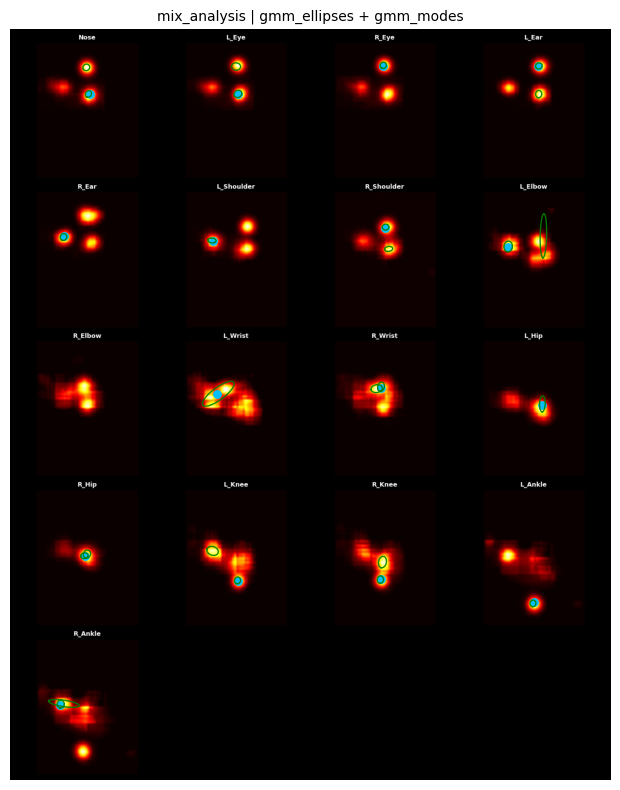

Overlays visibles: gmm_ellipses, gmm_modes


In [54]:
# Vista específica: mix_analysis con moda(s) de la GMM
mix = samples_by_slice.get("mix_analysis")
if mix is None:
    print("No existe slice mix_analysis")
else:
    img = np.array(Image.open(mix.filepath).convert("RGB"))
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)
    ax.set_title("mix_analysis | gmm_ellipses + gmm_modes")
    ax.axis("off")

    present = []
    if mix.has_field("gmm_ellipses") and mix["gmm_ellipses"] is not None:
        _draw_polylines(ax, mix["gmm_ellipses"], w, h, color="green", lw=1.0)
        present.append("gmm_ellipses")
    if mix.has_field("gmm_modes") and mix["gmm_modes"] is not None:
        _draw_keypoint_like(ax, mix["gmm_modes"], w, h, color="deepskyblue", size=28, alpha=1.0)
        present.append("gmm_modes")

    plt.tight_layout()
    display(fig)
    plt.close(fig)
    print("Overlays visibles:", ", ".join(present) if present else "ninguno")

## 9. Launch FiftyOne Interactive Session

In [55]:
# Ejecuta esta celda para abrir la App dentro de VS Code / navegador
# Puedes cambiar la vista inicial aquí: view_all / view_wins / view_regressions / view_high_uncertainty / view_edge_cases
initial_view = view_all

session = fo.launch_app(dataset, view=initial_view, auto=False)
print("Sesión lanzada.")
print("En tags puedes filtrar por: type:wins, type:regressions, type:high_uncertainty, type:edge_cases")
print("En campos puedes usar sample_type, tta_name y slice_display_name")
session

Session launched. Run `session.show()` to open the App in a cell output.
Sesión lanzada.
En tags puedes filtrar por: type:wins, type:regressions, type:high_uncertainty, type:edge_cases
En campos puedes usar sample_type, tta_name y slice_display_name


Dataset:          TFG_Debug_FiftyOne_Notebook
Media type:       group
Num samples:      6
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/
View stages:
    1. SelectGroupSlices(slices=['mix_analysis', 'original', 'tta_flip_heatmaps', ...], media_type=None, flat=True)
    2. SortBy(field_or_expr='file_size_bytes', reverse=True, create_index=False)

## 10. Quick Smoke Tests & Validation

In [56]:
assert len(dataset) > 0, "Dataset vacío"
assert dataset.first() is not None, "No hay primer sample"

expected_core_fields = {"group", "image_id", "file_size_bytes", "is_heatmap_slice", "status"}
actual_fields = set(dataset.get_field_schema().keys())
missing = expected_core_fields - actual_fields
assert not missing, f"Faltan campos: {missing}"

assert len(flat_view) >= 3, "flat_view debería tener varias slices"
assert len(view_original) >= 1, "No hay slice original"
assert len(view_heatmaps) >= 1, "No hay slices heatmap"

print("[OK] Smoke tests superados")
print("Dataset:", dataset_name)
print("Num groups:", len(dataset))
print("Num slices flat_view:", len(flat_view))
print("Slices únicas:", sorted({s['group'].name for s in flat_view}))

[OK] Smoke tests superados
Dataset: TFG_Debug_FiftyOne_Notebook
Num groups: 1
Num slices flat_view: 6
Slices únicas: ['mix_analysis', 'original', 'tta_flip_heatmaps', 'tta_flip_image', 'tta_original_heatmaps', 'tta_original_image']
